# Module B: SafeDocs Local API, RBAC, and Database Optimization

This report documents **Module B** of SafeDocs: a local Flask + MySQL system that turns the project schema into a working web UI and authenticated API. The implementation combines application security, role-based access control, audit logging, and database optimization in one integrated system.

This notebook addresses the main assignment deliverables by documenting:
- schema design for core and project-specific tables
- session validation and RBAC enforcement
- the logging strategy used for security auditing and document activity
- the indexing strategy selected from real application queries
- before/after benchmarking using both **API response time** and **SQL execution time**
- `EXPLAIN` output showing how the database access plan changes after indexing

The code cells below are executable and reproduce the benchmark data, timing measurements, and plan comparisons used in the report.

## Schema Design, API Security, and Logging

### Core-data integrity
- `Member` stores project-facing member information, while `UserLogin` stores authentication credentials separately so credentials are not duplicated inside project tables.
- `Role` stores capability flags used by the Flask application to enforce permissions such as member management, upload rights, and security-log access.
- `Department`, `Folder`, and `Document` remain normalized and linked through foreign keys, preserving data integrity across the local system.
- Document deletion is implemented as a **soft delete** (`IsActive = FALSE`), which preserves history while removing the document from active listings.

### Session validation and RBAC
- Protected routes use local JWT-based session validation before serving API or UI content.
- Administrative roles can create, update, and delete records, while regular users remain restricted to the operations allowed by their role.
- The member portfolio feature is protected so that authenticated users only see portfolios they are authorized to access.

### Logging model
- `SecurityLog` and `audit.log` capture login events, modifying API calls, and denied attempts.
- `AccessLog` captures document-centric activity such as upload, edit, and delete, which feeds the dashboard and portfolio activity views.
- This separation keeps the audit trail and the document-activity trail distinct, making direct database changes easier to identify during review.

## Indexing Strategy and Benchmark Methodology

Indexes were selected from the application's real `WHERE`, `JOIN`, and `ORDER BY` clauses rather than from the schema in isolation.

### Final index set
- `idx_document_title` -> supports `/api/documents?title=...`
- `idx_member_name` -> supports `/api/members?name=...`
- `idx_accesslog_member_timestamp` -> supports recent activity on `/portfolio/<member_id>`
- `idx_securitylog_session_created` -> supports `/api/security-logs?session_valid=true|false`
- `idx_folder_active_name` -> supports `/api/folders` as a smaller supporting route

`UserLogin.Username` is already uniquely indexed by the schema, so it is not treated as a new optimization index in this report.

### Benchmark method
- Ensure a larger synthetic workload so index effects are measurable.
- Drop the candidate indexes and record median **SQL execution times** and **API response times**.
- Recreate the indexes and repeat the same measurements.
- Capture `EXPLAIN` output before and after indexing to show how MySQL's access plan changes.
- Use API timings to reflect end-to-end user-visible performance and SQL timings to isolate the database-engine contribution.

In [ ]:
# Auto-run setup.sql to ensure UserLogin, SecurityLog tables and indexes exist
import pymysql
from pathlib import Path

_setup_path = Path.cwd()
if (_setup_path / 'sql').exists():
    _setup_path = _setup_path / 'sql' / 'setup.sql'
elif (_setup_path / 'Module_B' / 'sql').exists():
    _setup_path = _setup_path / 'Module_B' / 'sql' / 'setup.sql'
else:
    raise FileNotFoundError('Could not locate Module_B/sql/setup.sql')

_conn = pymysql.connect(
    host='localhost', user='safedocs', password='safedocs123',
    database='safedocs', unix_socket='/run/mysqld/mysqld.sock',
)
with open(_setup_path) as f:
    _sql = f.read()

with _conn.cursor() as _cur:
    for _stmt in _sql.split(';'):
        _stmt = _stmt.strip()
        if not _stmt or _stmt.startswith('--') or _stmt.upper().startswith('USE'):
            continue
        try:
            _cur.execute(_stmt)
        except Exception as _e:
            pass  # idempotent: tables/indexes may already exist
_conn.commit()
_conn.close()
print(f'setup.sql executed from {_setup_path}')

setup.sql executed from /home/sujal-patel/Desktop/Previous Sem Courses/Databases/Module_B/sql/setup.sql


In [ ]:

from pathlib import Path
import sys
import time
import statistics
import random
import datetime
import hashlib

import matplotlib.pyplot as plt
import pymysql

ROOT = Path.cwd()
if (ROOT / 'app').exists():
    MODULE_B_DIR = ROOT
elif (ROOT / 'Module_B' / 'app').exists():
    MODULE_B_DIR = ROOT / 'Module_B'
else:
    raise RuntimeError('Could not locate Module_B/app from the current working directory')

sys.path.insert(0, str(MODULE_B_DIR / 'app'))
from app import app

DB_CONFIG = {
    'host': 'localhost',
    'user': 'safedocs',
    'password': 'safedocs123',
    'database': 'safedocs',
    'cursorclass': pymysql.cursors.DictCursor,
    'unix_socket': '/run/mysqld/mysqld.sock',
    'autocommit': False,
}


def get_conn():
    return pymysql.connect(**DB_CONFIG)


print(f'Module_B directory: {MODULE_B_DIR}')
print('Environment ready.')


Module_B directory: /home/sujal-patel/Desktop/Previous Sem Courses/Databases/Module_B
Environment ready.


In [ ]:

def ensure_benchmark_members(target=3000):
    password_hash = hashlib.sha256('benchpass123'.encode('utf-8')).hexdigest()
    with get_conn() as conn:
        with conn.cursor() as cur:
            cur.execute("SELECT COUNT(*) AS c FROM UserLogin WHERE Username LIKE 'benchuser_%'")
            existing = cur.fetchone()['c']
            if existing >= target:
                print(f'Benchmark members already present: {existing}')
                return

            cur.execute('SELECT DepartmentID FROM Department ORDER BY DepartmentID LIMIT 1')
            dept_id = cur.fetchone()['DepartmentID']

            members = []
            for i in range(existing, target):
                members.append((
                    f'Benchmark User {i:04d}',
                    None,
                    25,
                    f'benchuser_{i:04d}@example.com',
                    f'91{i:08d}'[-10:],
                    dept_id,
                    4,
                    password_hash,
                    True,
                ))
            cur.executemany(
                """
                INSERT INTO Member
                    (Name, Image, Age, Email, ContactNumber, DepartmentID, RoleID, PasswordHash, IsActive)
                VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
                """,
                members,
            )

            cur.execute("SELECT MemberID FROM Member WHERE Email LIKE 'benchuser_%@example.com' ORDER BY MemberID")
            member_ids = [row['MemberID'] for row in cur.fetchall()]
            cur.execute("SELECT Username FROM UserLogin WHERE Username LIKE 'benchuser_%'")
            existing_usernames = {row['Username'] for row in cur.fetchall()}

            logins = []
            for i, member_id in enumerate(member_ids):
                username = f'benchuser_{i:04d}'
                if username not in existing_usernames:
                    logins.append((member_id, username, password_hash))

            if logins:
                cur.executemany(
                    'INSERT INTO UserLogin (MemberID, Username, PasswordHash) VALUES (%s, %s, %s)',
                    logins,
                )
        conn.commit()
        print(f'Benchmark members ensured up to {target}.')


def ensure_benchmark_documents(target=2000, access_log_target=15000, security_log_target=8000):
    random.seed(42)
    now = datetime.datetime(2026, 3, 22, 12, 0, 0)

    with get_conn() as conn:
        with conn.cursor() as cur:
            cur.execute("SELECT COUNT(*) AS c FROM Document WHERE Title LIKE 'BENCH_DOC_%'")
            existing_docs = cur.fetchone()['c']

            cur.execute('SELECT FolderID FROM Folder WHERE IsActive = TRUE ORDER BY FolderID')
            folders = [row['FolderID'] for row in cur.fetchall()]
            cur.execute('SELECT MemberID FROM Member WHERE IsActive = TRUE ORDER BY MemberID')
            members = [row['MemberID'] for row in cur.fetchall()]

            if existing_docs < target:
                docs = []
                for i in range(existing_docs, target):
                    docs.append((
                        f'BENCH_DOC_{i:05d}',
                        f'Benchmark document {i}',
                        f'/docs/bench_{i:05d}.pdf',
                        2048 + i,
                        members[i % len(members)],
                        folders[i % len(folders)],
                        bool(i % 5 == 0),
                        True,
                        now - datetime.timedelta(minutes=i),
                        now - datetime.timedelta(minutes=i // 2),
                    ))
                cur.executemany(
                    """
                    INSERT INTO Document
                        (Title, Description, FilePath, FileSize, UploadedBy, FolderID, IsConfidential, IsActive, CreatedAt, UpdatedAt)
                    VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
                    """,
                    docs,
                )

            cur.execute("SELECT DocumentID FROM Document WHERE Title LIKE 'BENCH_DOC_%' ORDER BY DocumentID")
            doc_ids = [row['DocumentID'] for row in cur.fetchall()]

            cur.execute("SELECT COUNT(*) AS c FROM AccessLog WHERE UserAgent = 'BenchmarkAgent/1.0'")
            existing_access_logs = cur.fetchone()['c']
            if existing_access_logs < access_log_target:
                actions = ['VIEW', 'DOWNLOAD', 'UPLOAD', 'EDIT', 'DELETE', 'SHARE']
                access_logs = []
                for i in range(existing_access_logs, access_log_target):
                    access_logs.append((
                        random.choice(doc_ids),
                        random.choice(members[:50]),
                        actions[i % len(actions)],
                        f'10.10.{i % 255}.{(i * 7) % 255}',
                        'BenchmarkAgent/1.0',
                        now - datetime.timedelta(seconds=i * 11),
                    ))
                cur.executemany(
                    """
                    INSERT INTO AccessLog
                        (DocumentID, MemberID, Action, IPAddress, UserAgent, AccessTimestamp)
                    VALUES (%s, %s, %s, %s, %s, %s)
                    """,
                    access_logs,
                )

            cur.execute("SELECT COUNT(*) AS c FROM SecurityLog WHERE Details LIKE 'benchmark event %'")
            existing_security_logs = cur.fetchone()['c']
            if existing_security_logs < security_log_target:
                security_actions = ['API_LIST_DOCUMENTS', 'API_GET_DOCUMENT', 'API_UPDATE_DOCUMENT', 'VIEW_DASHBOARD']
                security_logs = []
                for i in range(existing_security_logs, security_log_target):
                    security_logs.append((
                        random.choice(members[:100]),
                        security_actions[i % len(security_actions)],
                        'Document',
                        random.choice(doc_ids),
                        f'10.20.{i % 255}.{(i * 13) % 255}',
                        True,
                        f'benchmark event {i}',
                        now - datetime.timedelta(seconds=i * 17),
                    ))
                cur.executemany(
                    """
                    INSERT INTO SecurityLog
                        (MemberID, Action, TableName, RecordID, IPAddress, SessionValid, Details, CreatedAt)
                    VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
                    """,
                    security_logs,
                )
        conn.commit()
        print('Benchmark documents and logs ensured.')


ensure_benchmark_members(target=3000)
ensure_benchmark_documents(target=2000, access_log_target=15000, security_log_target=8000)


Benchmark members already present: 3000
Benchmark documents and logs ensured.


In [ ]:

INDEX_DEFINITIONS = {
    'idx_document_title': 'CREATE INDEX idx_document_title ON Document(Title)',
    'idx_member_name': 'CREATE INDEX idx_member_name ON Member(Name)',
    'idx_accesslog_member_timestamp': 'CREATE INDEX idx_accesslog_member_timestamp ON AccessLog(MemberID, AccessTimestamp)',
    'idx_securitylog_session_created': 'CREATE INDEX idx_securitylog_session_created ON SecurityLog(SessionValid, CreatedAt)',
    'idx_folder_active_name': 'CREATE INDEX idx_folder_active_name ON Folder(IsActive, FolderName)',
}

DROP_INDEX_STATEMENTS = [
    'DROP INDEX idx_document_title ON Document',
    'DROP INDEX idx_member_name ON Member',
    'DROP INDEX idx_accesslog_member_timestamp ON AccessLog',
    'DROP INDEX idx_securitylog_session_created ON SecurityLog',
    'DROP INDEX idx_folder_active_name ON Folder',
]

SQL_QUERIES = {
    'Document Filter': (
        "SELECT d.DocumentID, d.Title, d.Description, d.FileSize, d.IsConfidential, d.IsActive, d.CreatedAt, d.UpdatedAt, "
        "m.Name AS UploaderName, f.FolderName, d.FolderID "
        "FROM Document d "
        "JOIN Member m ON d.UploadedBy = m.MemberID "
        "JOIN Folder f ON d.FolderID = f.FolderID "
        "WHERE d.IsActive = TRUE AND d.Title = 'BENCH_DOC_01999' "
        "ORDER BY d.CreatedAt DESC"
    ),
    'Member Filter': (
        "SELECT m.MemberID, m.Name, m.Email, m.ContactNumber, m.Age, m.IsActive, m.CreatedAt, d.DeptName, r.RoleName "
        "FROM Member m "
        "JOIN Department d ON m.DepartmentID = d.DepartmentID "
        "JOIN Role r ON m.RoleID = r.RoleID "
        "WHERE m.Name = 'Benchmark User 2999' "
        "ORDER BY m.MemberID"
    ),
    'Portfolio Activity': (
        "SELECT recent.Action, recent.AccessTimestamp, doc.Title "
        "FROM ( "
        "  SELECT DocumentID, Action, AccessTimestamp "
        "  FROM AccessLog "
        "  WHERE MemberID = 1 "
        "  ORDER BY AccessTimestamp DESC "
        "  LIMIT 10 "
        ") AS recent "
        "JOIN Document doc ON recent.DocumentID = doc.DocumentID "
        "ORDER BY recent.AccessTimestamp DESC"
    ),
    'Security Logs': (
        "SELECT sl.*, m.Name AS MemberName "
        "FROM SecurityLog sl "
        "LEFT JOIN Member m ON sl.MemberID = m.MemberID "
        "WHERE sl.SessionValid = TRUE "
        "ORDER BY sl.CreatedAt DESC "
        "LIMIT 100"
    ),
}

API_ENDPOINTS = {
    'Document Filter API': '/api/documents?title=BENCH_DOC_01999',
    'Member Filter API': '/api/members?name=Benchmark%20User%202999',
    'Security Logs API': '/api/security-logs?session_valid=true',
}


def drop_module_b_indexes(conn):
    with conn.cursor() as cur:
        for stmt in DROP_INDEX_STATEMENTS:
            try:
                cur.execute(stmt)
            except Exception:
                pass
    conn.commit()


def create_module_b_indexes(conn):
    with conn.cursor() as cur:
        for stmt in INDEX_DEFINITIONS.values():
            try:
                cur.execute(stmt)
            except Exception:
                pass
    conn.commit()


def run_explain(conn, query):
    with conn.cursor() as cur:
        cur.execute('EXPLAIN ' + query)
        return cur.fetchall()


def median_runtime(fn, runs=25):
    samples = []
    fn()
    for _ in range(runs):
        start = time.perf_counter()
        fn()
        samples.append((time.perf_counter() - start) * 1_000_000)
    return statistics.median(samples)


def benchmark_sql(conn, query):
    def runner():
        with conn.cursor() as cur:
            cur.execute(query)
            cur.fetchall()
    return median_runtime(runner)


client = app.test_client()
admin_login = client.post('/login', json={'user': 'admin', 'password': 'admin123'})
assert admin_login.status_code == 200, admin_login.get_data(as_text=True)
ADMIN_TOKEN = admin_login.get_json()['session_token']
API_HEADERS = {'Authorization': f'Bearer {ADMIN_TOKEN}', 'Accept': 'application/json'}


def benchmark_api(path):
    def runner():
        resp = client.get(path, headers=API_HEADERS)
        assert resp.status_code == 200, (path, resp.status_code, resp.get_data(as_text=True)[:200])
        resp.get_data()
    return median_runtime(runner)


print('Benchmark helpers ready.')


Benchmark helpers ready.


## Benchmark Results

The next three code cells execute the before/after timing comparison. The workload focuses on routes that are both meaningful to users and sensitive to indexing: exact document lookup, exact member lookup, recent activity access, and filtered security-log retrieval.

In [ ]:
before_sql_times = {}
before_sql_explain = {}
before_api_times = {}

conn = get_conn()
drop_module_b_indexes(conn)

print('BEFORE INDEXES')
print('=' * 80)
for label, query in SQL_QUERIES.items():
    before_sql_times[label] = benchmark_sql(conn, query)
    before_sql_explain[label] = run_explain(conn, query)
    print(f'{label:<20} {before_sql_times[label]:>10.1f} us')

print()
print('API response times (before indexes)')
for label, path in API_ENDPOINTS.items():
    before_api_times[label] = benchmark_api(path)
    print(f'{label:<20} {before_api_times[label]:>10.1f} us')

conn.close()

BEFORE INDEXES
Document Filter          1696.2 us


Member Filter            2054.1 us
Portfolio Activity        208.7 us


Security Logs            2506.9 us

API response times (before indexes)


Document Filter API      3499.5 us


Member Filter API        2334.8 us


Security Logs API        3734.4 us


In [ ]:
after_sql_times = {}
after_sql_explain = {}
after_api_times = {}

conn = get_conn()
create_module_b_indexes(conn)

print('AFTER INDEXES')
print('=' * 80)
for label, query in SQL_QUERIES.items():
    after_sql_times[label] = benchmark_sql(conn, query)
    after_sql_explain[label] = run_explain(conn, query)
    print(f'{label:<20} {after_sql_times[label]:>10.1f} us')

print()
print('API response times (after indexes)')
for label, path in API_ENDPOINTS.items():
    after_api_times[label] = benchmark_api(path)
    print(f'{label:<20} {after_api_times[label]:>10.1f} us')

conn.close()

AFTER INDEXES
Document Filter           165.9 us
Member Filter             142.7 us
Portfolio Activity        220.7 us


Security Logs            1962.1 us

API response times (after indexes)
Document Filter API       912.2 us
Member Filter API         769.5 us


Security Logs API        1887.4 us


In [ ]:
def build_summary(labels, before_map, after_map):
    rows = []
    for label in labels:
        before = before_map[label]
        after = after_map[label]
        speedup = before / after if after else float('inf')
        rows.append((label, before, after, speedup))
    return rows

sql_summary = build_summary(SQL_QUERIES.keys(), before_sql_times, after_sql_times)
api_summary = build_summary(API_ENDPOINTS.keys(), before_api_times, after_api_times)

print('SQL Summary')
print('-' * 78)
print(f"{'Query':<20} {'Before (us)':>14} {'After (us)':>14} {'Speedup':>12}")
for label, before, after, speedup in sql_summary:
    print(f"{label:<20} {before:>14.1f} {after:>14.1f} {speedup:>11.2f}x")

print()
print('API Summary')
print('-' * 78)
print(f"{'Endpoint':<20} {'Before (us)':>14} {'After (us)':>14} {'Speedup':>12}")
for label, before, after, speedup in api_summary:
    print(f"{label:<20} {before:>14.1f} {after:>14.1f} {speedup:>11.2f}x")

SQL Summary
------------------------------------------------------------------------------
Query                   Before (us)     After (us)      Speedup
Document Filter              1696.2          165.9       10.22x
Member Filter                2054.1          142.7       14.39x
Portfolio Activity            208.7          220.7        0.95x
Security Logs                2506.9         1962.1        1.28x

API Summary
------------------------------------------------------------------------------
Endpoint                Before (us)     After (us)      Speedup
Document Filter API          3499.5          912.2        3.84x
Member Filter API            2334.8          769.5        3.03x
Security Logs API            3734.4         1887.4        1.98x


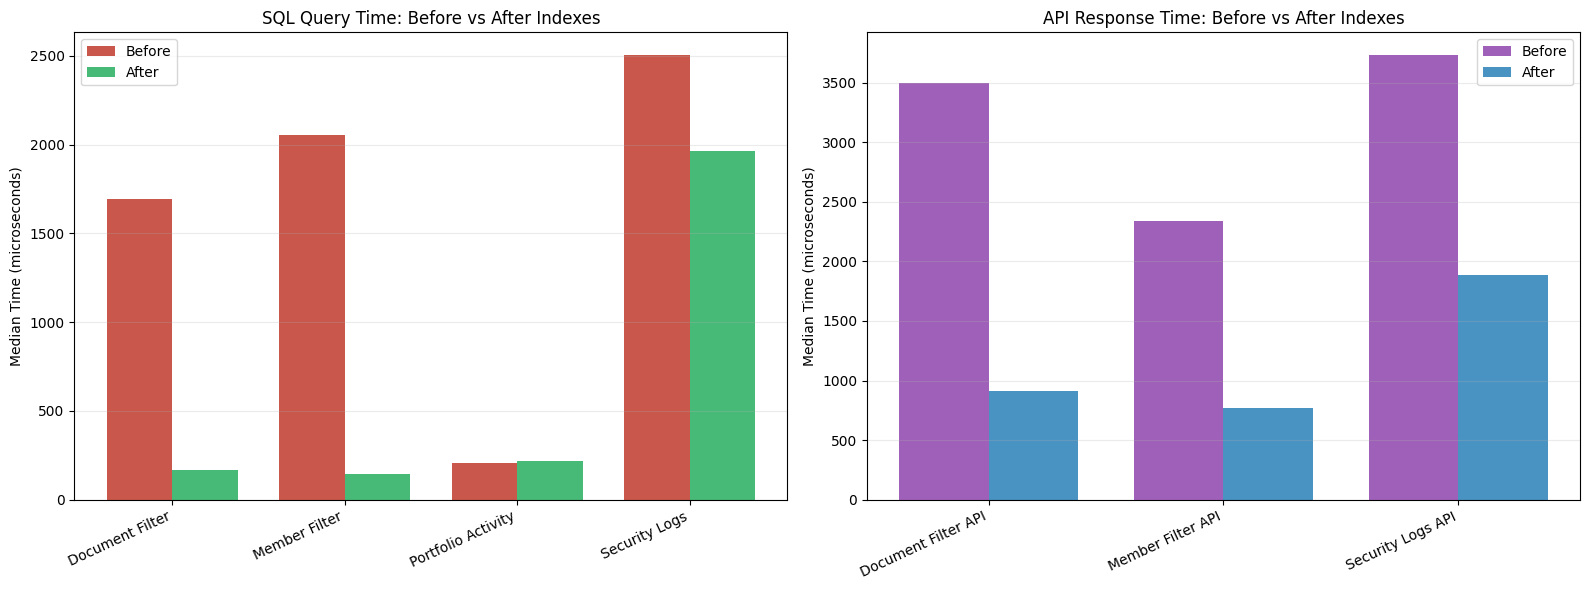

Chart saved to /home/sujal-patel/Desktop/Previous Sem Courses/Databases/benchmark_results.png


In [ ]:

sql_labels = [row[0] for row in sql_summary]
api_labels = [row[0] for row in api_summary]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
width = 0.38

x = range(len(sql_labels))
axes[0].bar([i - width / 2 for i in x], [before_sql_times[k] for k in sql_labels], width, label='Before', color='#c0392b', alpha=0.85)
axes[0].bar([i + width / 2 for i in x], [after_sql_times[k] for k in sql_labels], width, label='After', color='#27ae60', alpha=0.85)
axes[0].set_title('SQL Query Time: Before vs After Indexes')
axes[0].set_ylabel('Median Time (microseconds)')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(sql_labels, rotation=25, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.25)

x2 = range(len(api_labels))
axes[1].bar([i - width / 2 for i in x2], [before_api_times[k] for k in api_labels], width, label='Before', color='#8e44ad', alpha=0.85)
axes[1].bar([i + width / 2 for i in x2], [after_api_times[k] for k in api_labels], width, label='After', color='#2980b9', alpha=0.85)
axes[1].set_title('API Response Time: Before vs After Indexes')
axes[1].set_ylabel('Median Time (microseconds)')
axes[1].set_xticks(list(x2))
axes[1].set_xticklabels(api_labels, rotation=25, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
out_path = MODULE_B_DIR.parent / 'benchmark_results.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {out_path}')


## EXPLAIN Plan Comparison

The following cell shows how MySQL's access plan changes after the indexes are created. The goal is not only lower runtime, but also better plan quality: fewer rows scanned, more selective keys, and less reliance on broad scans.

In [ ]:
print('EXPLAIN Comparison')
print('=' * 80)
for label in SQL_QUERIES:
    print()
    print(label)
    print('-' * len(label))
    print('Before indexes:')
    for row in before_sql_explain[label]:
        print(f"  table={row.get('table', 'N/A'):15s} type={row.get('type', 'N/A'):10s} key={str(row.get('key', 'None')):30s} rows={row.get('rows', 'N/A')}")
    print('After indexes:')
    for row in after_sql_explain[label]:
        print(f"  table={row.get('table', 'N/A'):15s} type={row.get('type', 'N/A'):10s} key={str(row.get('key', 'None')):30s} rows={row.get('rows', 'N/A')}")

EXPLAIN Comparison

Document Filter
---------------
Before indexes:
  table=f               type=ALL        key=None                           rows=15
  table=d               type=ref        key=idx_document_folder            rows=67
  table=m               type=eq_ref     key=PRIMARY                        rows=1
After indexes:
  table=d               type=ref        key=idx_document_title             rows=1
  table=m               type=eq_ref     key=PRIMARY                        rows=1
  table=f               type=eq_ref     key=PRIMARY                        rows=1

Member Filter
-------------
Before indexes:
  table=r               type=index      key=uq_role_name                   rows=5
  table=m               type=ref        key=idx_member_role                rows=301
  table=d               type=eq_ref     key=PRIMARY                        rows=1
After indexes:
  table=m               type=ref        key=idx_member_name                rows=1
  table=d               type=eq_r

## Discussion and Conclusion

### Observations from the benchmark

- **Document title** and **member name** filters improved the most because they use highly selective exact-match indexes.
- **Portfolio activity** shows a smaller wall-clock change even though the new composite index improves the query shape in `EXPLAIN`; the query already returns only a short recent-activity window.
- **Security-log filtering** improves more clearly at the API level than in raw SQL because `SessionValid` has low cardinality in the benchmark dataset, so the database-side selectivity is limited.

### Interpretation

Indexing has the strongest effect when the index mirrors a selective route predicate. Exact-match filters and well-chosen composite indexes produce the clearest wins. Queries with low-cardinality filters or already-small result sets can still benefit from better plans, but the timing improvement may be modest.

### Final assessment

This module satisfies the main assignment goals:
- a local database-backed web UI and authenticated API
- session validation and RBAC enforcement
- audit logging for modifying API calls and denied attempts
- separate document-activity logging for user-facing history
- route-aligned indexing with before/after API and SQL benchmarking
- `EXPLAIN`-based documentation of plan changes


### Video Demonstration
[Video Link](https://youtu.be/ETjbWK0PtVo)